<a href="https://www.kaggle.com/code/lalit7881/social-media-addiction-mental-wellbeing-eda-78?scriptVersionId=337312490" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/harpartapsingh13/social-media-addiction-and-mental-wellbeing-dataset/social_media_addiction_mental_wellbeing.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/harpartapsingh13/social-media-addiction-and-mental-wellbeing-dataset/social_media_addiction_mental_wellbeing.csv")

In [3]:
df.head()

,User_ID,Age,Gender,Occupation,Relationship_Status,Primary_Platform,Daily_Usage_Hours,Platforms_Used_Count,Posts_Per_Week,Late_Night_Usage,...,Loneliness_Score,Self_Esteem_Score,Sleep_Quality_Score,Sleep_Hours,Productivity_Loss_Score,Offline_Relationship_Quality,Physical_Activity_Hrs_Week,Screen_Free_Time_Hrs,Mental_Wellbeing_Score,Addiction_Level
0,USR00001,30,Male,Working Professional,In a Relationship,YouTube,2.9,4,3,No,...,1.7,6.5,8.5,5.3,3.7,3.8,5.8,3.1,7.3,Low
1,USR00002,19,Male,Student,Married,Instagram,4.8,1,0,NaN,...,7.0,7.5,7.8,5.5,4.0,1.8,0.9,3.3,4.1,Severe
2,USR00003,40,Male,Student,In a Relationship,YouTube,NaN,4,5,No,...,5.6,5.3,6.3,NaN,5.8,2.8,0.0,1.5,5.6,High
3,USR00004,37,Female,Student,Married,Facebook,7.7,2,3,Yes,...,5.6,1.4,3.9,6.1,5.5,3.6,1.0,3.9,4.3,Severe
4,USR00005,18,Non-binary,Student,In a Relationship,TikTok,4.6,3,0,No,...,4.0,NaN,5.7,5.0,3.8,3.2,0.6,1.0,6.6,Moderate


In [4]:
df.tail()

,User_ID,Age,Gender,Occupation,Relationship_Status,Primary_Platform,Daily_Usage_Hours,Platforms_Used_Count,Posts_Per_Week,Late_Night_Usage,...,Loneliness_Score,Self_Esteem_Score,Sleep_Quality_Score,Sleep_Hours,Productivity_Loss_Score,Offline_Relationship_Quality,Physical_Activity_Hrs_Week,Screen_Free_Time_Hrs,Mental_Wellbeing_Score,Addiction_Level
1495,USR01496,40,Male,Working Professional,In a Relationship,TikTok,2.7,2,4,No,...,3.3,7.4,8.5,6.7,4.5,7.6,2.3,2.3,6.5,High
1496,USR01497,23,Non-binary,Student,Married,YouTube,3.5,3,6,Yes,...,4.2,1.9,7.2,6.9,7.2,NaN,2.8,2.0,6.4,Moderate
1497,USR01498,39,Female,Student,Single,Instagram,5.3,2,3,Yes,...,0.4,2.4,5.1,NaN,6.4,7.8,2.6,4.8,4.7,Severe
1498,USR01499,26,Female,Freelancer,Single,Twitter/X,7.3,4,0,Yes,...,7.5,6.6,6.4,4.2,9.1,6.4,3.6,2.1,6.4,High
1499,USR01500,16,Female,Working Professional,In a Relationship,TikTok,0.7,3,2,No,...,5.9,8.5,5.3,7.2,3.4,2.3,3.9,3.1,6.1,Moderate


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   User_ID                       1500 non-null   object 
 1   Age                           1500 non-null   int64  
 2   Gender                        1447 non-null   object 
 3   Occupation                    1455 non-null   object 
 4   Relationship_Status           1449 non-null   object 
 5   Primary_Platform              1447 non-null   object 
 6   Daily_Usage_Hours             1444 non-null   float64
 7   Platforms_Used_Count          1500 non-null   int64  
 8   Posts_Per_Week                1500 non-null   int64  
 9   Late_Night_Usage              1450 non-null   object 
 10  First_Check_Morning           1500 non-null   object 
 11  Notifications_Per_Day         1500 non-null   int64  
 12  FOMO_Score                    1445 non-null   float64
 13  Soc

In [6]:
df.describe()

,Age,Daily_Usage_Hours,Platforms_Used_Count,Posts_Per_Week,Notifications_Per_Day,FOMO_Score,Social_Comparison_Score,Validation_Seeking_Score,Scroll_Without_Purpose,Anxiety_Score,Depression_Score,Loneliness_Score,Self_Esteem_Score,Sleep_Quality_Score,Sleep_Hours,Productivity_Loss_Score,Offline_Relationship_Quality,Physical_Activity_Hrs_Week,Screen_Free_Time_Hrs,Mental_Wellbeing_Score
count,1500.000000,1444.000000,1500.000000,1500.000000,1500.000000,1445.000000,1449.000000,1442.000000,1500.000000,1452.000000,1445.000000,1445.000000,1431.000000,1432.000000,1438.000000,1449.000000,1430.000000,1449.000000,1440.000000,1500.000000
mean,29.372000,4.521399,3.236000,3.936000,60.244667,5.445882,5.495514,5.013107,5.449867,5.110537,4.562630,4.484429,5.519846,5.508659,6.557580,5.026570,5.482797,3.016494,3.025903,6.429733
std,8.550459,2.108319,1.682714,1.948273,33.150688,2.183914,2.041919,2.112417,2.083848,2.157587,2.199201,1.997623,1.993134,1.997842,1.380144,2.114049,2.045514,1.715963,1.691351,1.299288
min,15.000000,0.500000,1.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,1.500000
25%,22.000000,3.100000,2.000000,3.000000,36.000000,4.000000,4.100000,3.600000,4.000000,3.700000,3.100000,3.100000,4.200000,4.100000,5.600000,3.600000,4.100000,1.800000,1.800000,5.500000
50%,29.000000,4.400000,3.000000,4.000000,59.000000,5.500000,5.500000,5.000000,5.500000,5.100000,4.500000,4.500000,5.600000,5.500000,6.600000,5.000000,5.400000,3.000000,3.000000,6.400000
75%,37.000000,5.900000,4.000000,5.000000,81.250000,7.000000,6.900000,6.500000,6.900000,6.600000,6.000000,5.900000,6.900000,6.900000,7.500000,6.400000,7.000000,4.200000,4.200000,7.300000
max,44.000000,12.000000,8.000000,12.000000,165.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,8.900000,10.300000,10.000000


In [7]:
df.isnull().sum()

User_ID                          0
Age                              0
Gender                          53
Occupation                      45
Relationship_Status             51
Primary_Platform                53
Daily_Usage_Hours               56
Platforms_Used_Count             0
Posts_Per_Week                   0
Late_Night_Usage                50
First_Check_Morning              0
Notifications_Per_Day            0
FOMO_Score                      55
Social_Comparison_Score         51
Validation_Seeking_Score        58
Scroll_Without_Purpose           0
Tried_To_Cut_Back               41
Failed_To_Cut_Back              43
Anxiety_Score                   48
Depression_Score                55
Loneliness_Score                55
Self_Esteem_Score               69
Sleep_Quality_Score             68
Sleep_Hours                     62
Productivity_Loss_Score         51
Offline_Relationship_Quality    70
Physical_Activity_Hrs_Week      51
Screen_Free_Time_Hrs            60
Mental_Wellbeing_Sco

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

User_ID                          object
Age                               int64
Gender                           object
Occupation                       object
Relationship_Status              object
Primary_Platform                 object
Daily_Usage_Hours               float64
Platforms_Used_Count              int64
Posts_Per_Week                    int64
Late_Night_Usage                 object
First_Check_Morning              object
Notifications_Per_Day             int64
FOMO_Score                      float64
Social_Comparison_Score         float64
Validation_Seeking_Score        float64
Scroll_Without_Purpose          float64
Tried_To_Cut_Back                object
Failed_To_Cut_Back               object
Anxiety_Score                   float64
Depression_Score                float64
Loneliness_Score                float64
Self_Esteem_Score               float64
Sleep_Quality_Score             float64
Sleep_Hours                     float64
Productivity_Loss_Score         float64


In [10]:
df.shape

(1500, 30)

In [11]:
df.columns

Index(['User_ID', 'Age', 'Gender', 'Occupation', 'Relationship_Status',
       'Primary_Platform', 'Daily_Usage_Hours', 'Platforms_Used_Count',
       'Posts_Per_Week', 'Late_Night_Usage', 'First_Check_Morning',
       'Notifications_Per_Day', 'FOMO_Score', 'Social_Comparison_Score',
       'Validation_Seeking_Score', 'Scroll_Without_Purpose',
       'Tried_To_Cut_Back', 'Failed_To_Cut_Back', 'Anxiety_Score',
       'Depression_Score', 'Loneliness_Score', 'Self_Esteem_Score',
       'Sleep_Quality_Score', 'Sleep_Hours', 'Productivity_Loss_Score',
       'Offline_Relationship_Quality', 'Physical_Activity_Hrs_Week',
       'Screen_Free_Time_Hrs', 'Mental_Wellbeing_Score', 'Addiction_Level'],
      dtype='object')

In [12]:
df.nunique()

User_ID                         1500
Age                               30
Gender                             3
Occupation                         4
Relationship_Status                3
Primary_Platform                   6
Daily_Usage_Hours                100
Platforms_Used_Count               8
Posts_Per_Week                    13
Late_Night_Usage                   2
First_Check_Morning                3
Notifications_Per_Day            142
FOMO_Score                       100
Social_Comparison_Score           97
Validation_Seeking_Score          98
Scroll_Without_Purpose           100
Tried_To_Cut_Back                  2
Failed_To_Cut_Back                 2
Anxiety_Score                    101
Depression_Score                 100
Loneliness_Score                  98
Self_Esteem_Score                 98
Sleep_Quality_Score              100
Sleep_Hours                       70
Productivity_Loss_Score          100
Offline_Relationship_Quality      96
Physical_Activity_Hrs_Week        81
S

## EDA

    User_ID  Age      Gender            Occupation Relationship_Status  \
0  USR00001   30        Male  Working Professional   In a Relationship   
1  USR00002   19        Male               Student             Married   
2  USR00003   40        Male               Student   In a Relationship   
3  USR00004   37      Female               Student             Married   
4  USR00005   18  Non-binary               Student   In a Relationship   

  Primary_Platform  Daily_Usage_Hours  Platforms_Used_Count  Posts_Per_Week  \
0          YouTube                2.9                     4               3   
1        Instagram                4.8                     1               0   
2          YouTube                NaN                     4               5   
3         Facebook                7.7                     2               3   
4           TikTok                4.6                     3               0   

  Late_Night_Usage  ... Loneliness_Score  Self_Esteem_Score  \
0               N

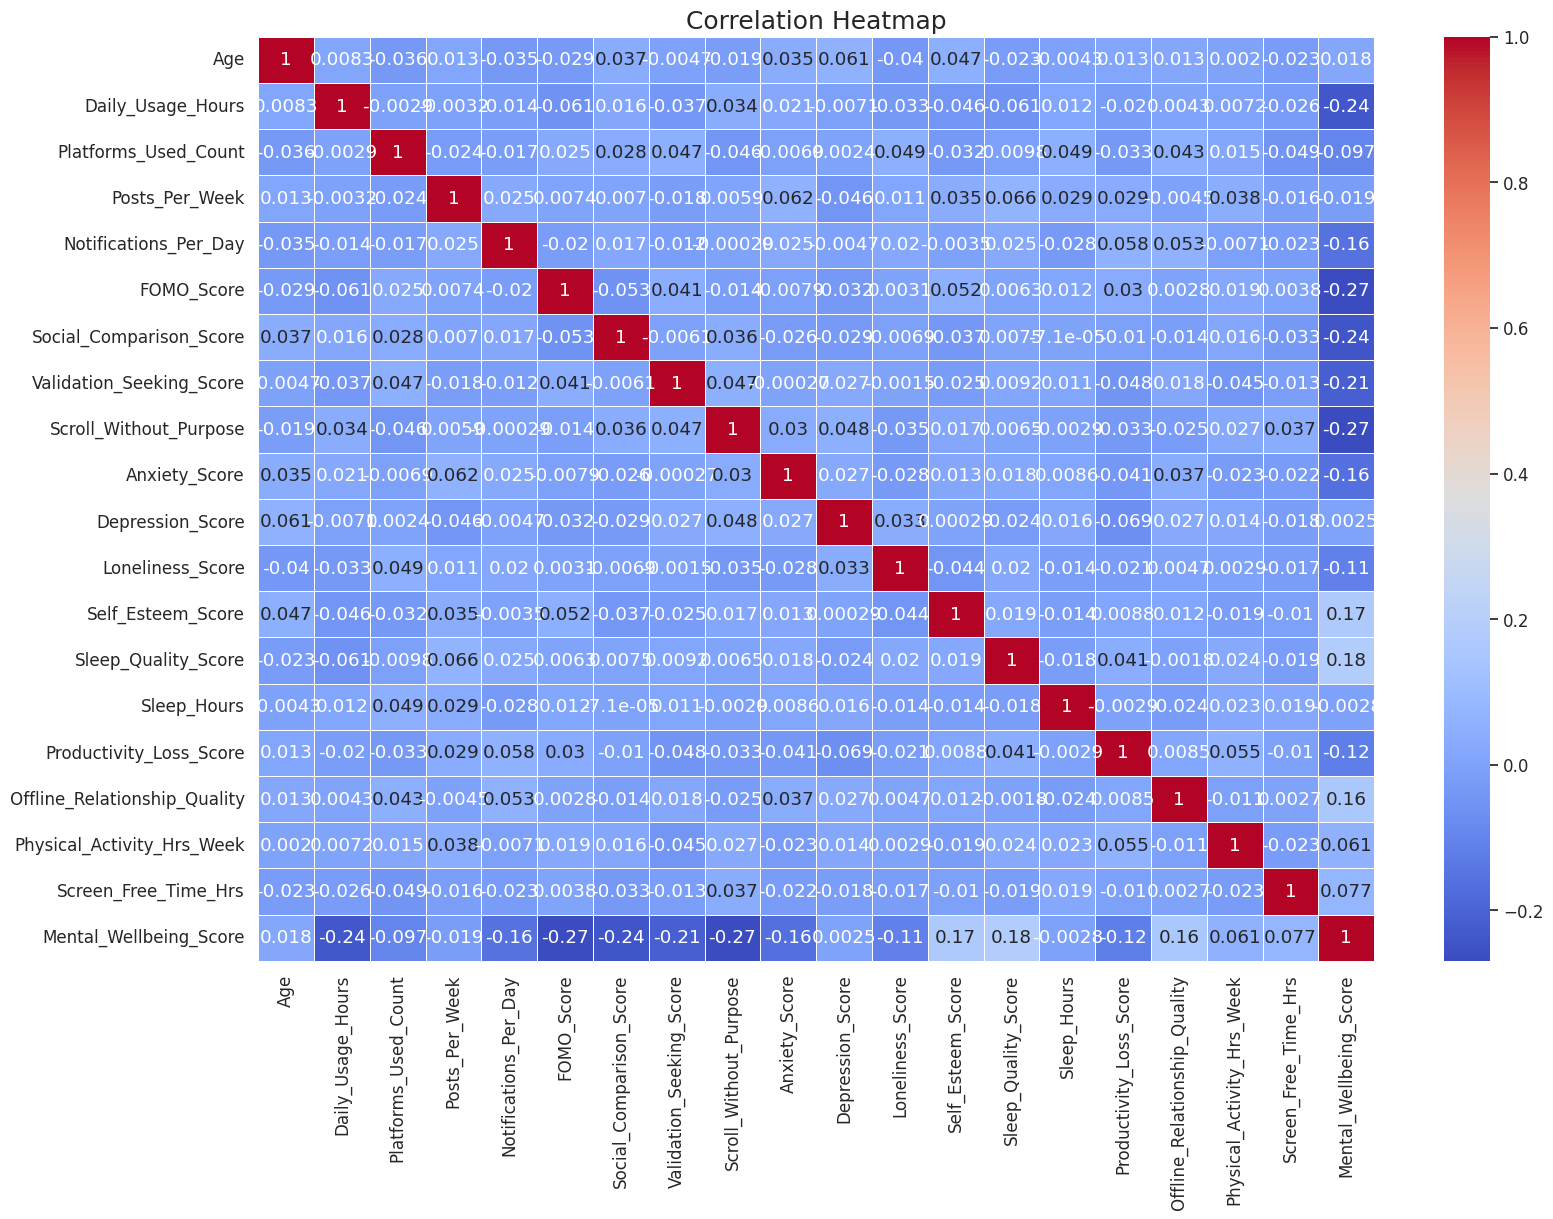

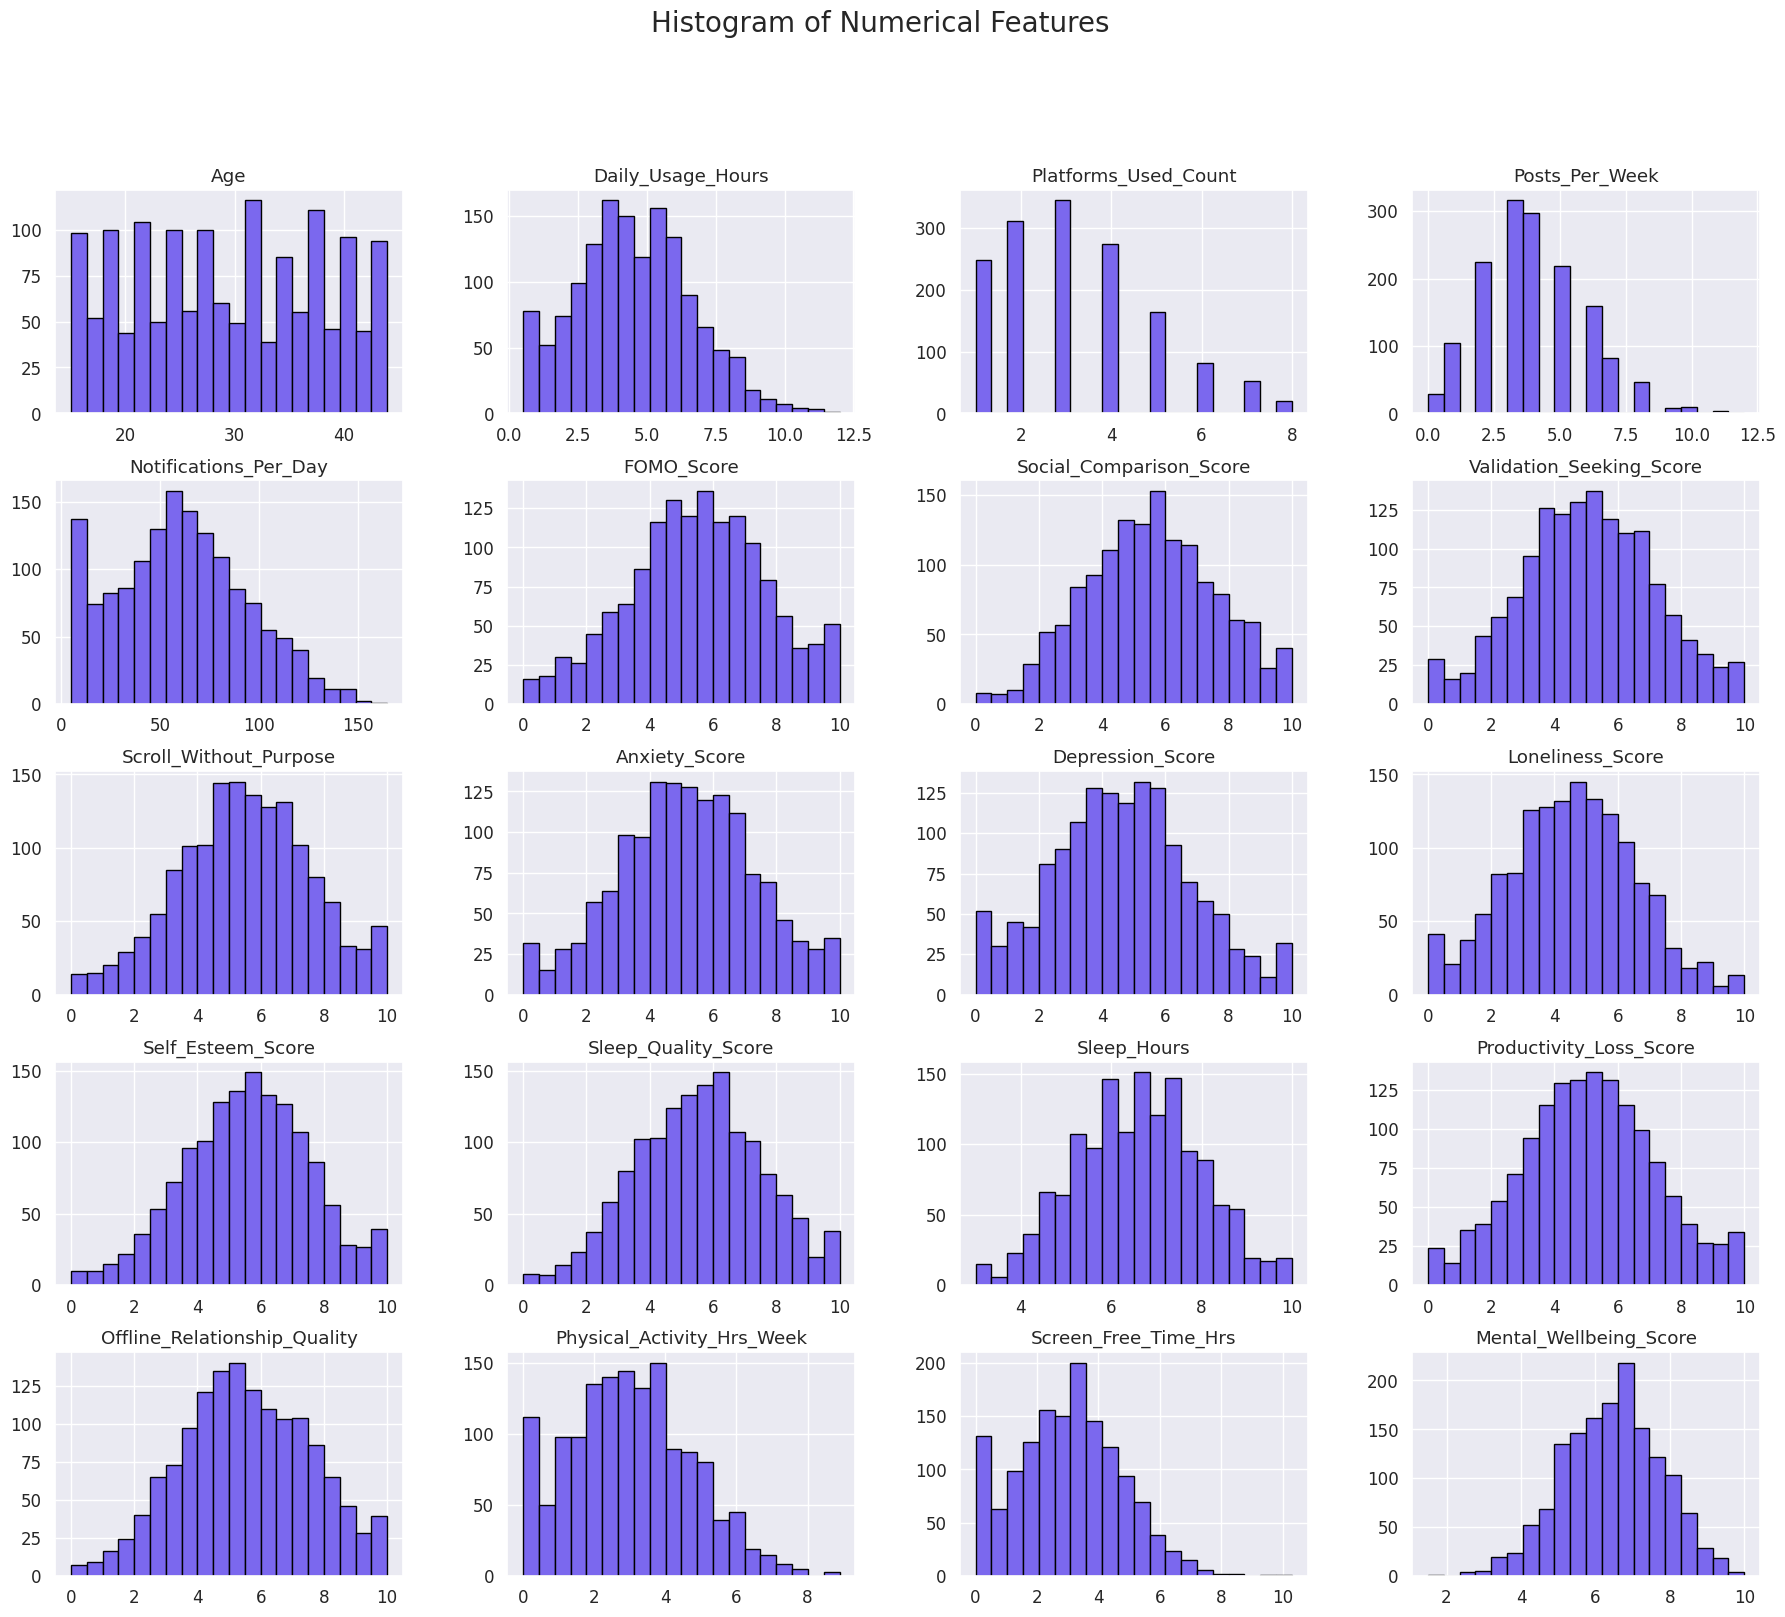

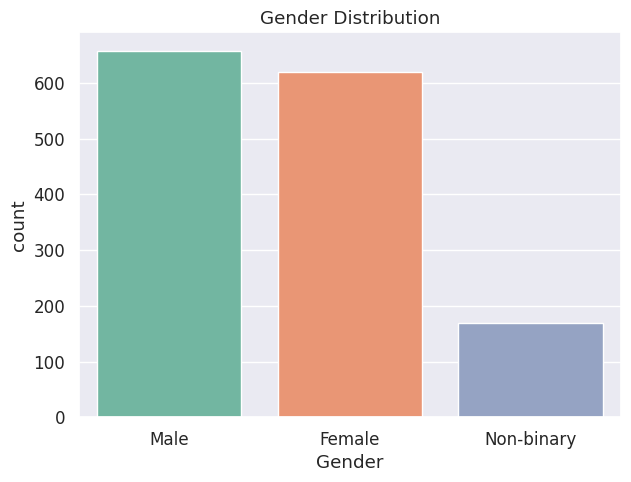

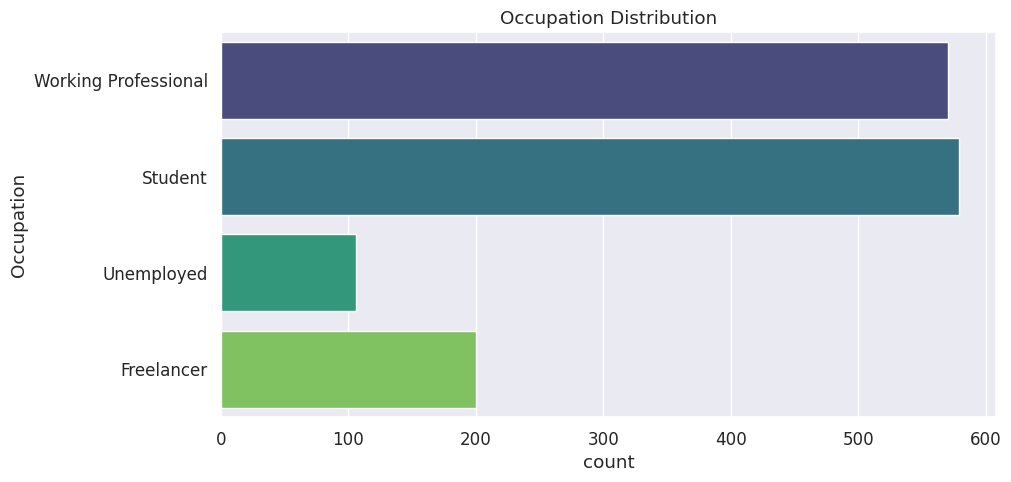

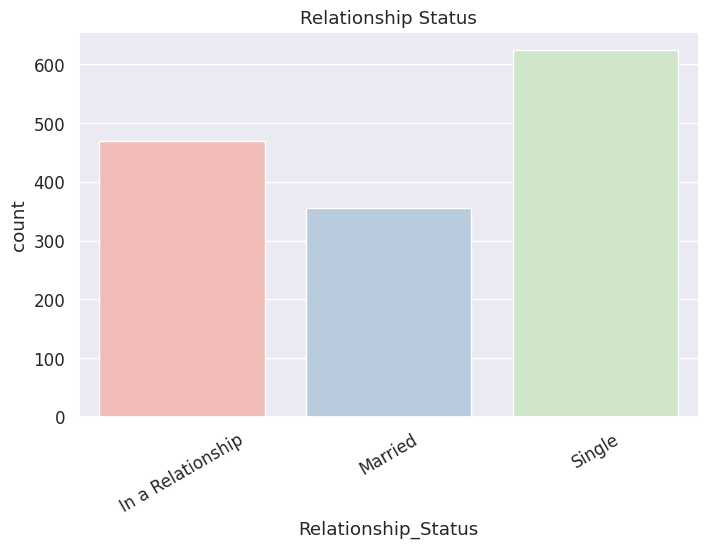

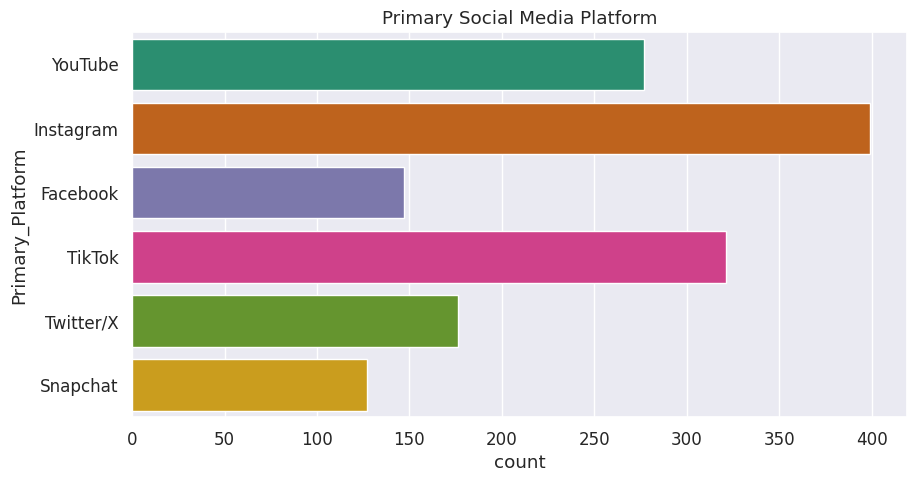

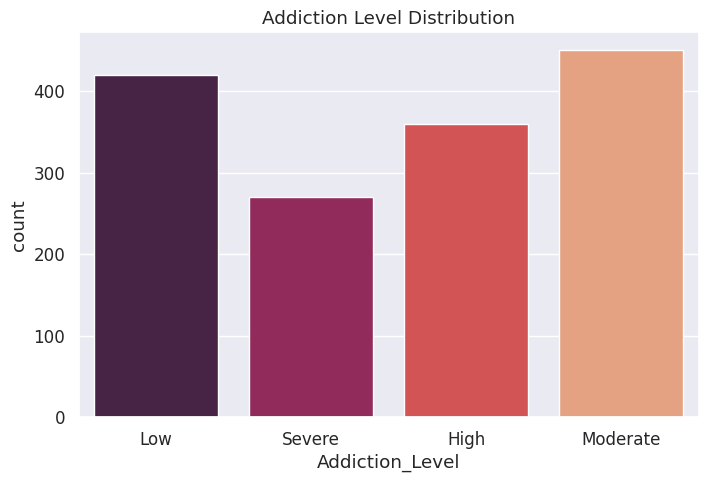

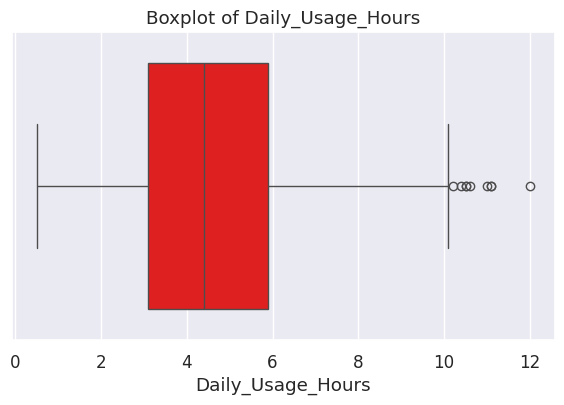

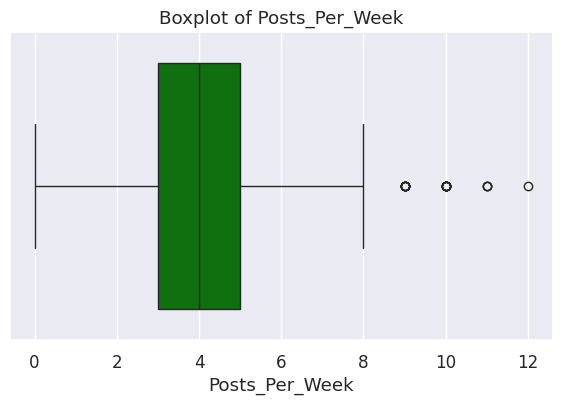

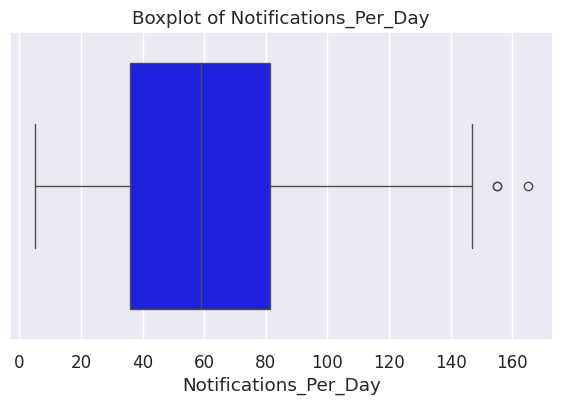

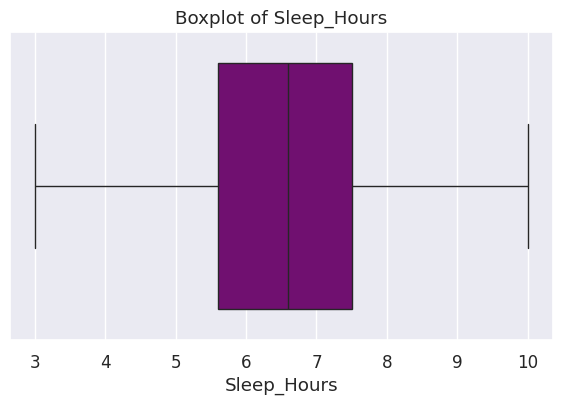

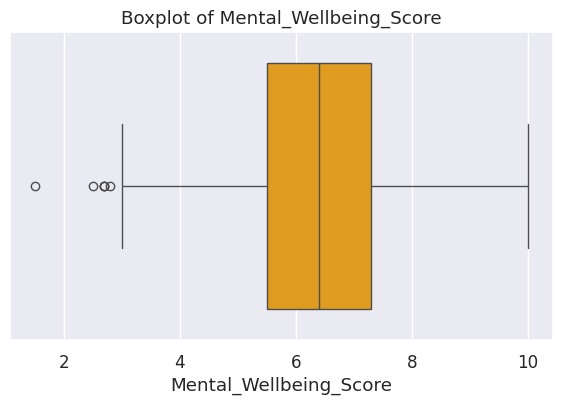

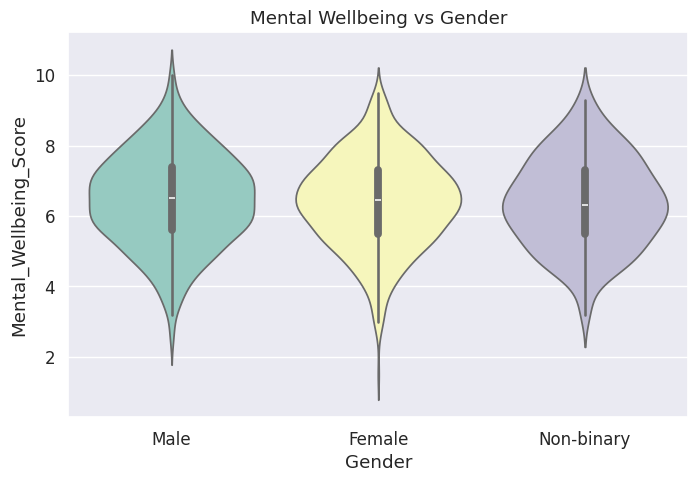

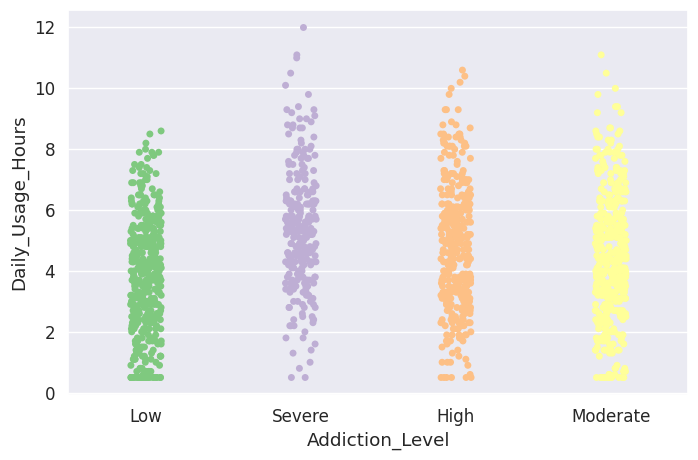

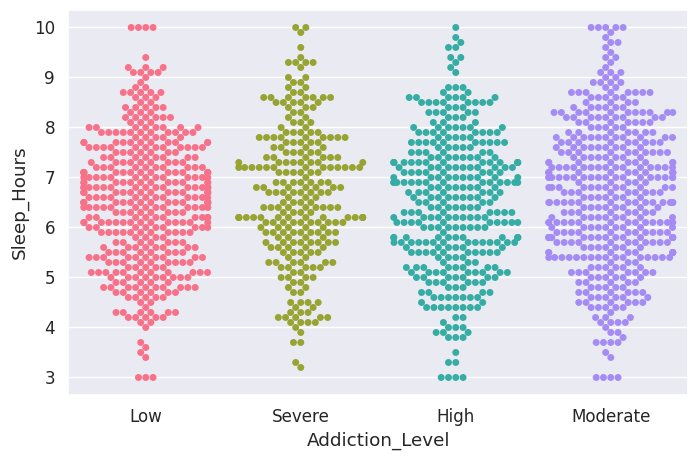

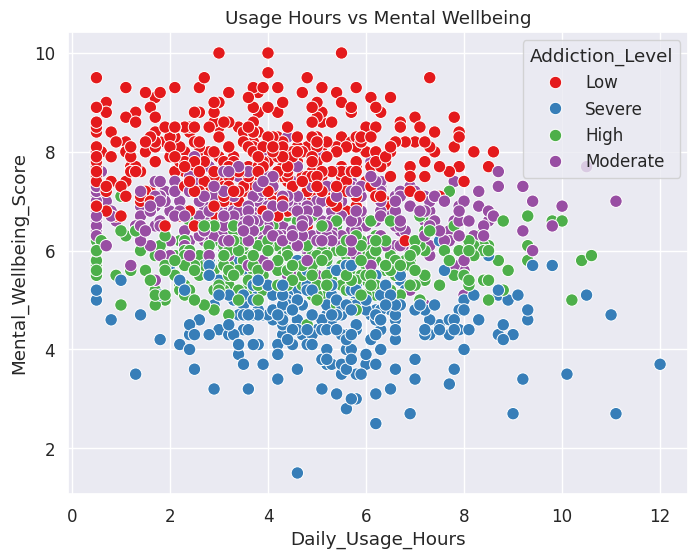

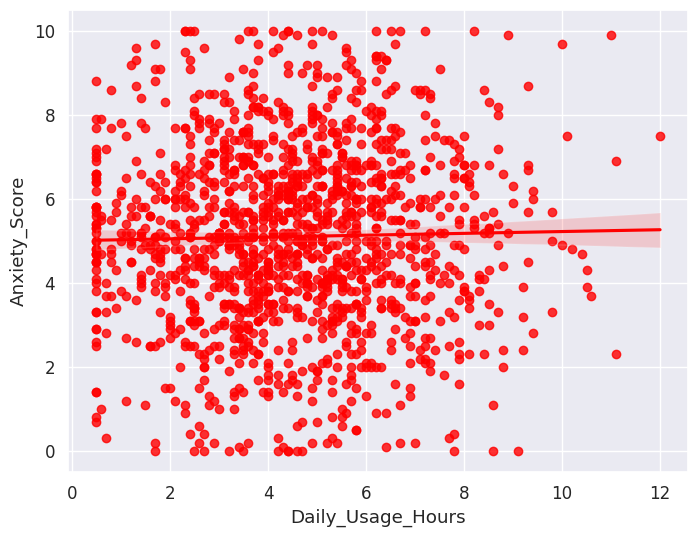

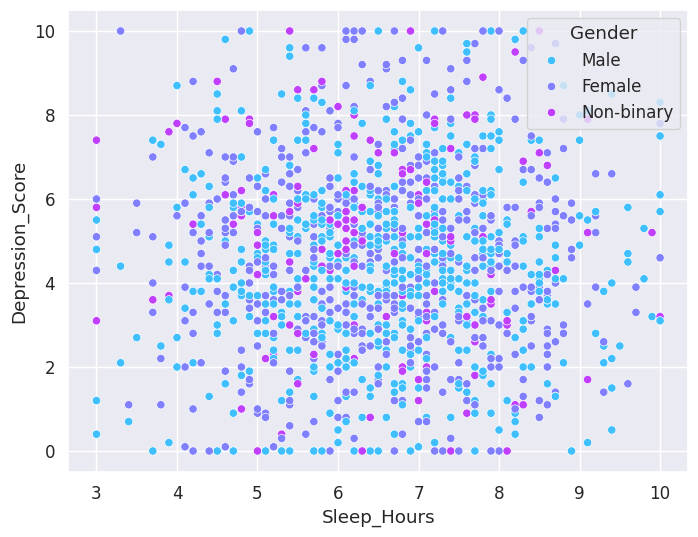

<Figure size 1000x500 with 0 Axes>

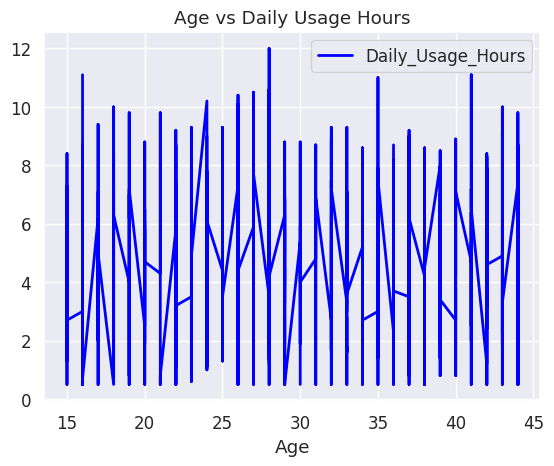

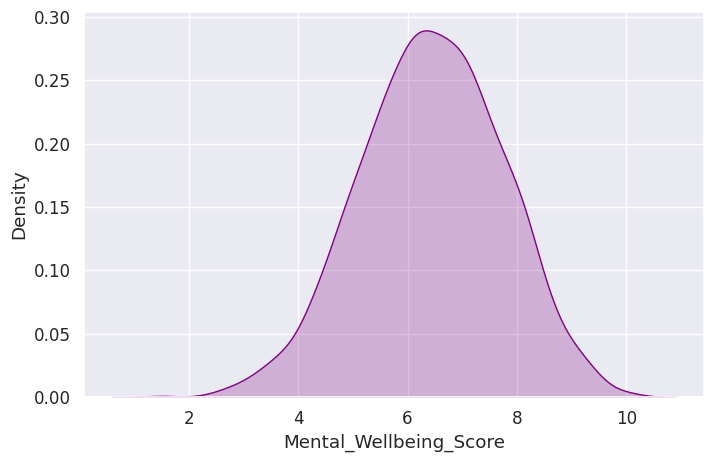

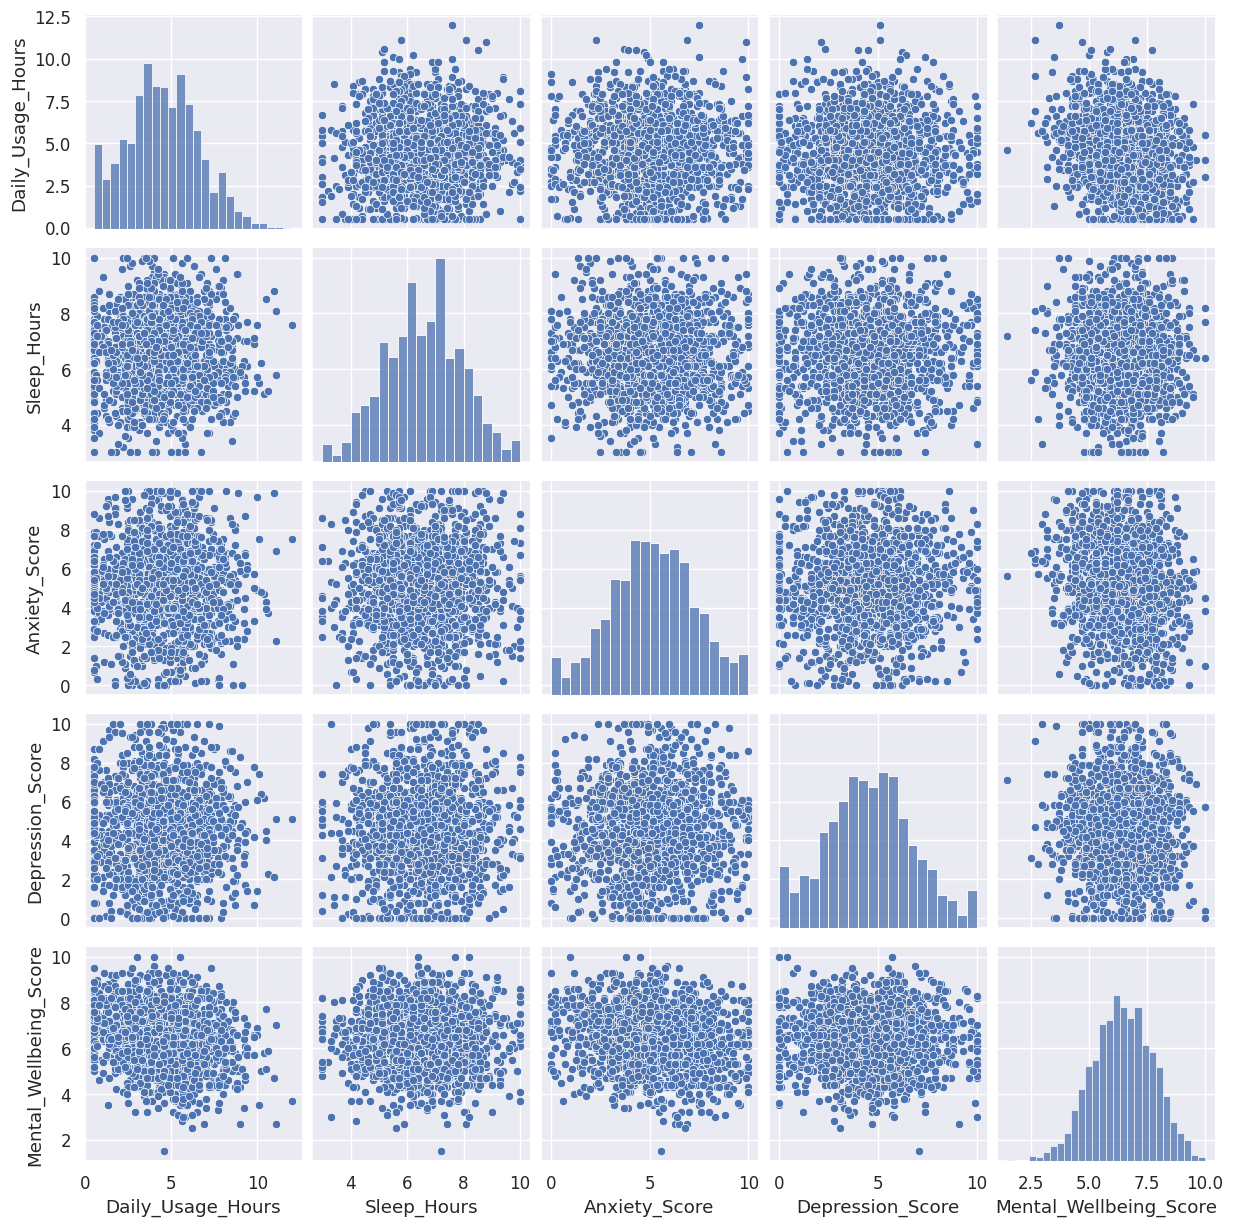

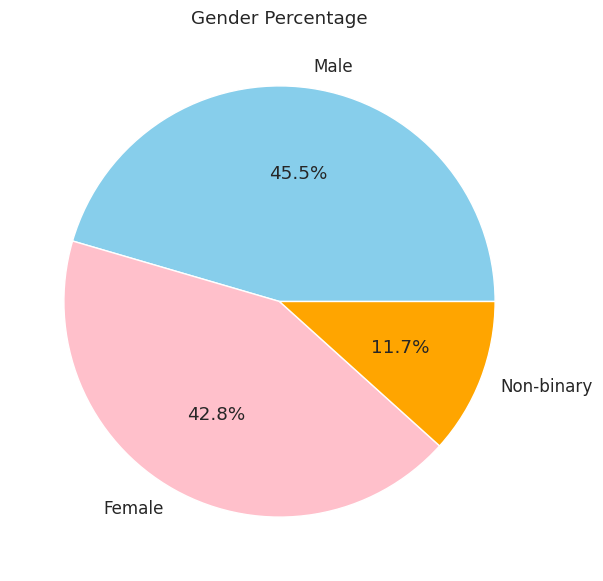

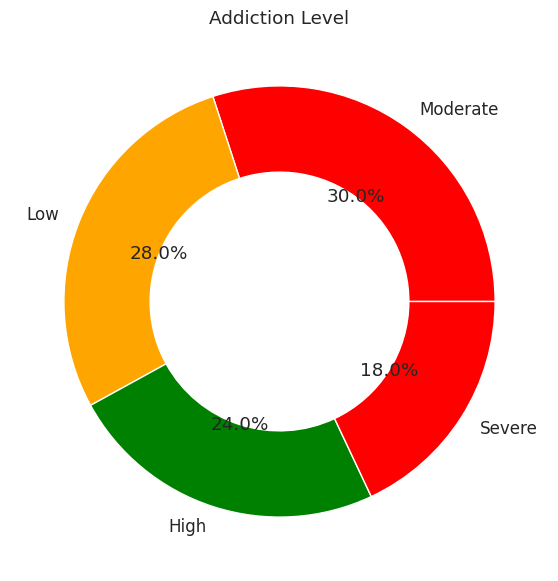

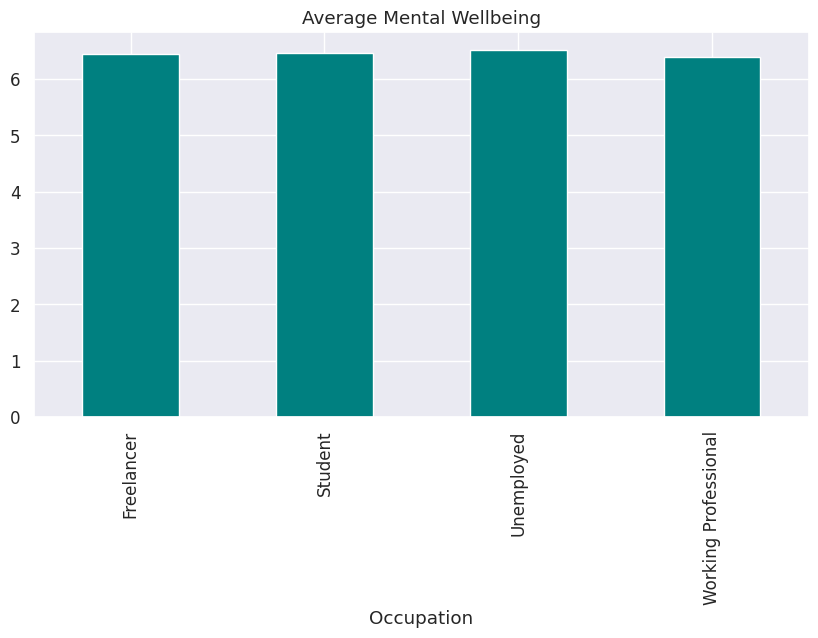

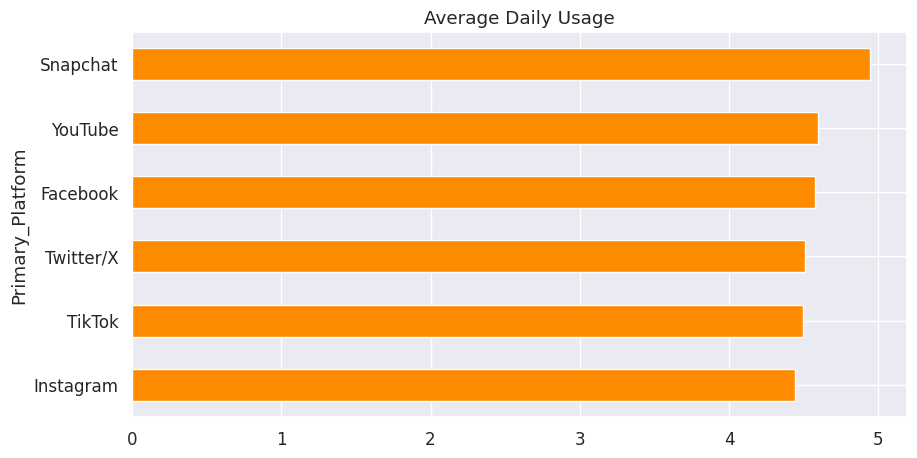

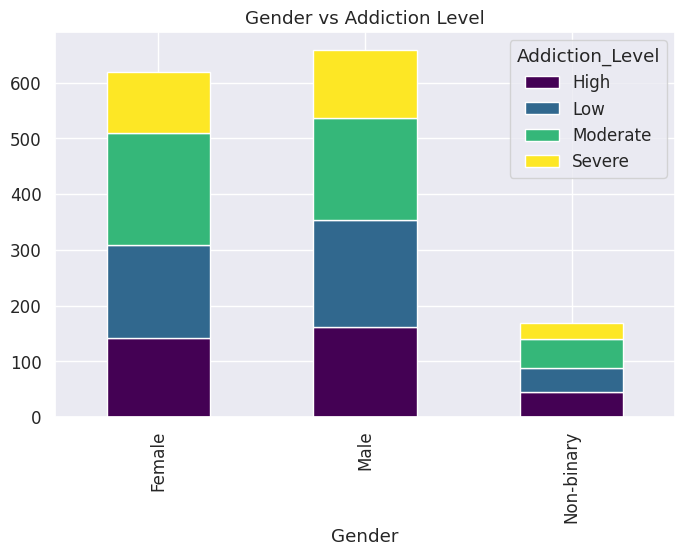

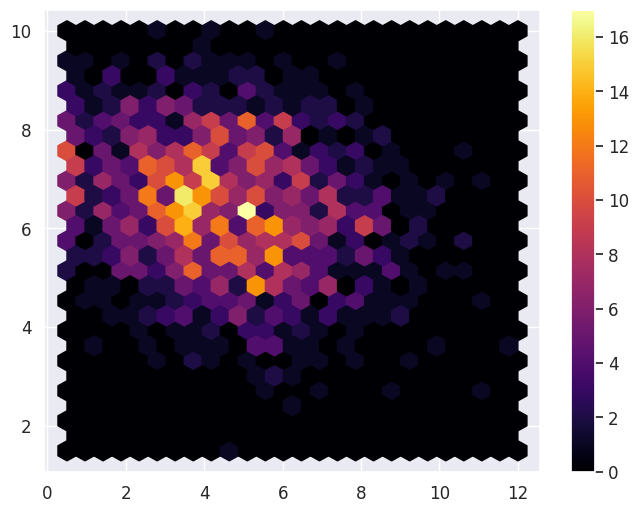

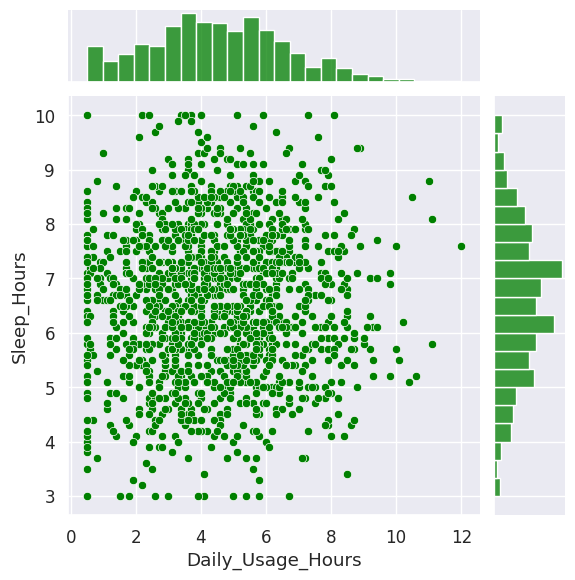

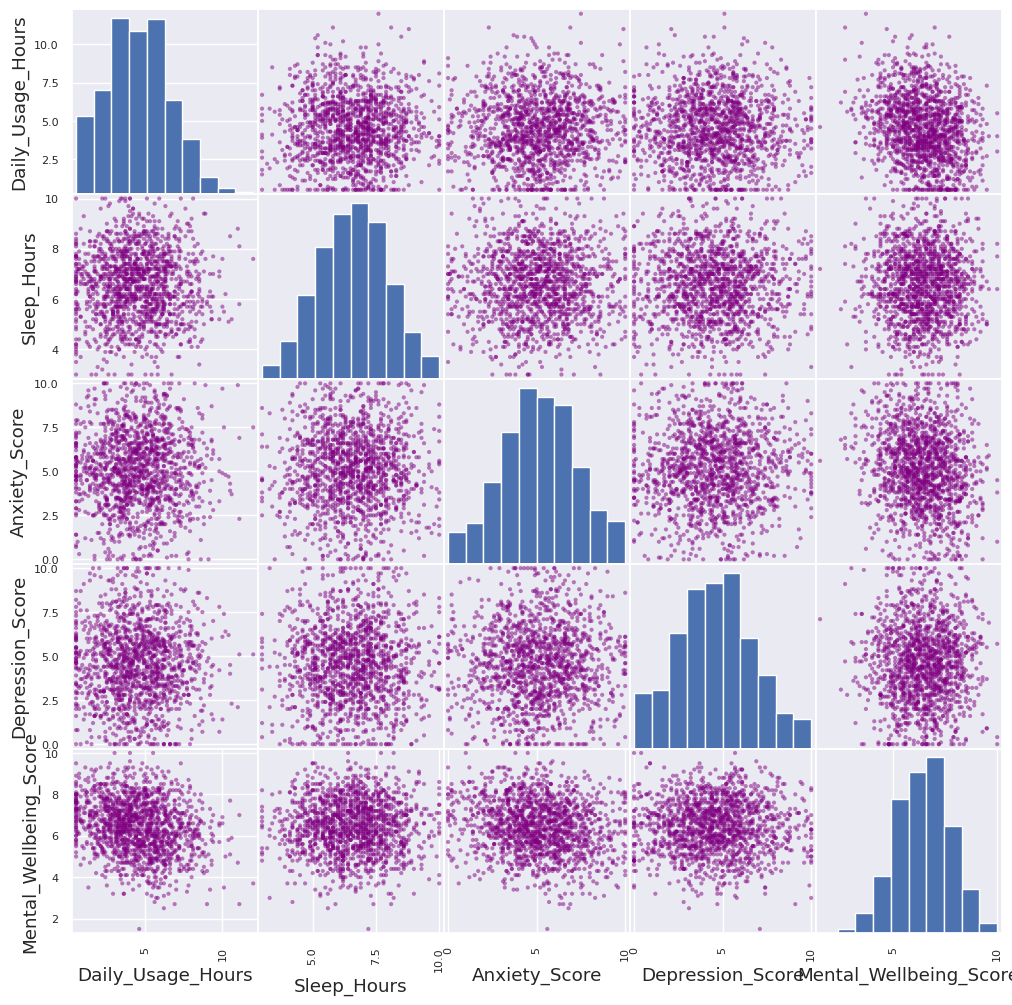

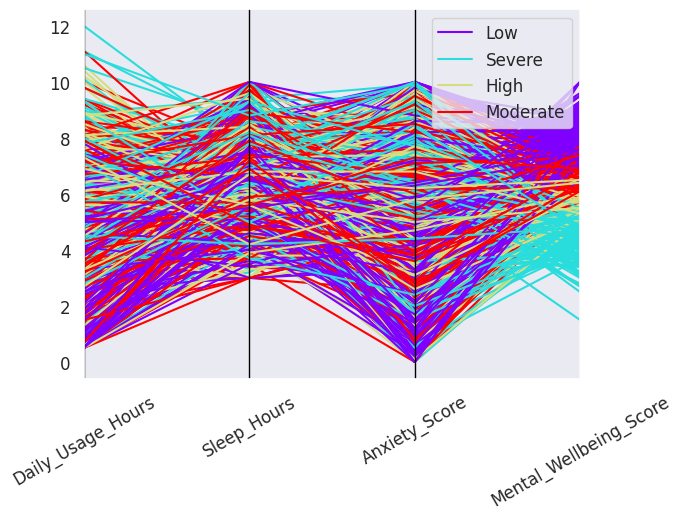

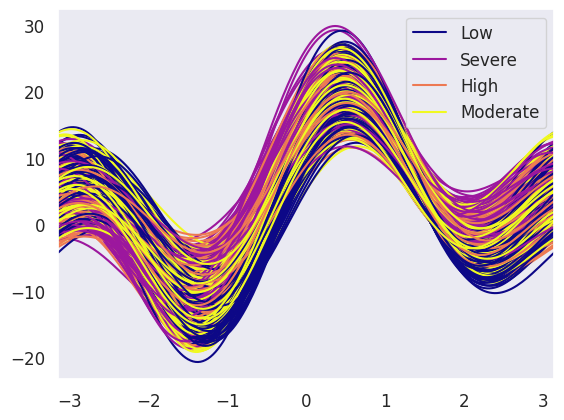

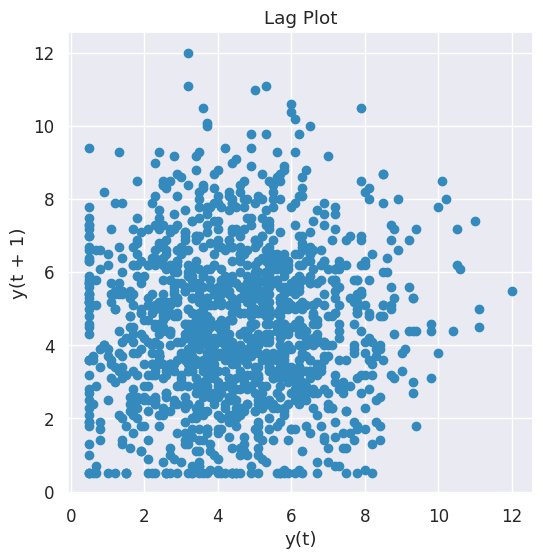

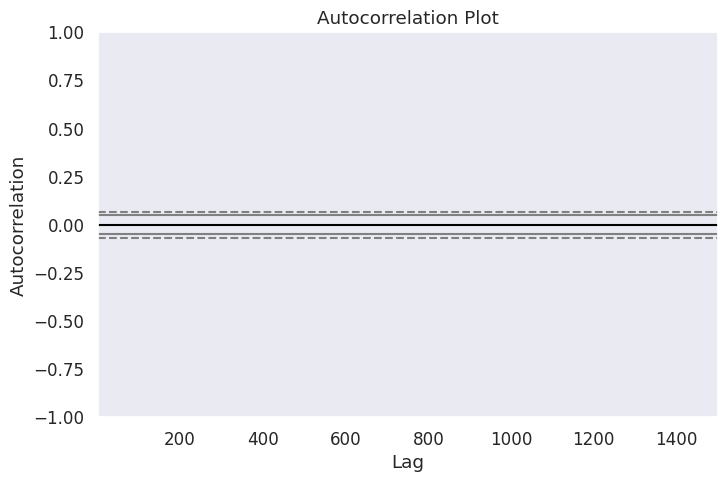

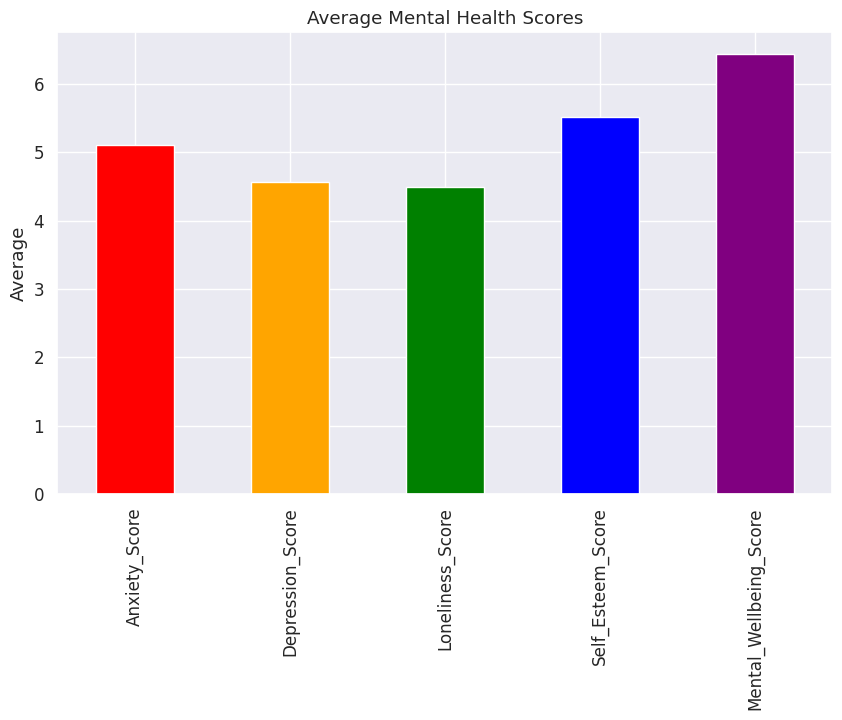

EDA Completed Successfully


In [13]:
from pandas.plotting import (
    scatter_matrix,
    parallel_coordinates,
    andrews_curves,
    lag_plot,
    autocorrelation_plot
)

# Plot Settings
plt.style.use("ggplot")
sns.set(font_scale=1.1)


# Display first rows
print(df.head())

# Shape
print(df.shape)

# Information
print(df.info())

# Statistical Summary
print(df.describe())

# Missing Values
print(df.isnull().sum())

# Duplicate Values
print("Duplicates :",df.duplicated().sum())

# ===================================
# Correlation Heatmap
# ===================================

plt.figure(figsize=(18,12))

corr=df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap",fontsize=18)
plt.show()

# ===================================
# Histograms
# ===================================

numeric=df.select_dtypes(include=np.number)

numeric.hist(
    figsize=(22,18),
    bins=20,
    color="mediumslateblue",
    edgecolor="black"
)

plt.suptitle("Histogram of Numerical Features",fontsize=20)

plt.show()

# ===================================
# Count Plot Gender
# ===================================

plt.figure(figsize=(7,5))

sns.countplot(
    x="Gender",
    data=df,
    palette="Set2"
)

plt.title("Gender Distribution")
plt.show()

# ===================================
# Occupation Count Plot
# ===================================

plt.figure(figsize=(10,5))

sns.countplot(
    y="Occupation",
    data=df,
    palette="viridis"
)

plt.title("Occupation Distribution")
plt.show()

# ===================================
# Relationship Status
# ===================================

plt.figure(figsize=(8,5))

sns.countplot(
    x="Relationship_Status",
    data=df,
    palette="Pastel1"
)

plt.xticks(rotation=30)

plt.title("Relationship Status")

plt.show()

# ===================================
# Primary Platform
# ===================================

plt.figure(figsize=(10,5))

sns.countplot(
    y="Primary_Platform",
    data=df,
    palette="Dark2"
)

plt.title("Primary Social Media Platform")

plt.show()

# ===================================
# Addiction Level
# ===================================

plt.figure(figsize=(8,5))

sns.countplot(
    x="Addiction_Level",
    data=df,
    palette="rocket"
)

plt.title("Addiction Level Distribution")

plt.show()

# ===================================
# Boxplots
# ===================================

cols=[
'Daily_Usage_Hours',
'Posts_Per_Week',
'Notifications_Per_Day',
'Sleep_Hours',
'Mental_Wellbeing_Score'
]

colors=[
"red",
"green",
"blue",
"purple",
"orange"
]

for col,color in zip(cols,colors):

    plt.figure(figsize=(7,4))

    sns.boxplot(
        x=df[col],
        color=color
    )

    plt.title(f"Boxplot of {col}")

    plt.show()

# ===================================
# Violin Plot
# ===================================

plt.figure(figsize=(8,5))

sns.violinplot(
    x="Gender",
    y="Mental_Wellbeing_Score",
    data=df,
    palette="Set3"
)

plt.title("Mental Wellbeing vs Gender")

plt.show()

# ===================================
# Strip Plot
# ===================================

plt.figure(figsize=(8,5))

sns.stripplot(
    x="Addiction_Level",
    y="Daily_Usage_Hours",
    data=df,
    palette="Accent"
)

plt.show()

# ===================================
# Swarm Plot
# ===================================

plt.figure(figsize=(8,5))

sns.swarmplot(
    x="Addiction_Level",
    y="Sleep_Hours",
    data=df,
    palette="husl"
)

plt.show()

# ===================================
# Scatter Plot
# ===================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Daily_Usage_Hours",
    y="Mental_Wellbeing_Score",
    hue="Addiction_Level",
    palette="Set1",
    data=df,
    s=80
)

plt.title("Usage Hours vs Mental Wellbeing")

plt.show()

# ===================================
# Regression Plot
# ===================================

plt.figure(figsize=(8,6))

sns.regplot(
    x="Daily_Usage_Hours",
    y="Anxiety_Score",
    data=df,
    color="red"
)

plt.show()

# ===================================
# Scatter Plot
# ===================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Sleep_Hours",
    y="Depression_Score",
    hue="Gender",
    palette="cool",
    data=df
)

plt.show()

# ===================================
# Line Plot
# ===================================

plt.figure(figsize=(10,5))

df.sort_values("Age").plot(
    x="Age",
    y="Daily_Usage_Hours",
    color="blue",
    linewidth=2
)

plt.title("Age vs Daily Usage Hours")

plt.show()

# ===================================
# KDE Plot
# ===================================

plt.figure(figsize=(8,5))

sns.kdeplot(
    df["Mental_Wellbeing_Score"],
    fill=True,
    color="purple"
)

plt.show()

# ===================================
# Pair Plot
# ===================================

pair=df[[
'Daily_Usage_Hours',
'Sleep_Hours',
'Anxiety_Score',
'Depression_Score',
'Mental_Wellbeing_Score'
]]

sns.pairplot(
    pair,
    palette="husl"
)

plt.show()

# ===================================
# Pie Chart
# ===================================

plt.figure(figsize=(7,7))

df["Gender"].value_counts().plot.pie(
    autopct="%1.1f%%",
    colors=["skyblue","pink","orange","green"]
)

plt.ylabel("")

plt.title("Gender Percentage")

plt.show()

# ===================================
# Donut Chart
# ===================================

plt.figure(figsize=(7,7))

sizes=df["Addiction_Level"].value_counts()

colors=["red","orange","green"]

plt.pie(
    sizes,
    labels=sizes.index,
    autopct="%1.1f%%",
    colors=colors,
    wedgeprops=dict(width=0.4)
)

plt.title("Addiction Level")

plt.show()

# ===================================
# Bar Chart
# ===================================

plt.figure(figsize=(10,5))

df.groupby("Occupation")["Mental_Wellbeing_Score"].mean().plot.bar(
    color="teal"
)

plt.title("Average Mental Wellbeing")

plt.show()

# ===================================
# Horizontal Bar
# ===================================

plt.figure(figsize=(10,5))

df.groupby("Primary_Platform")["Daily_Usage_Hours"].mean().sort_values().plot.barh(
    color="darkorange"
)

plt.title("Average Daily Usage")

plt.show()

# ===================================
# Stacked Bar Chart
# ===================================

pd.crosstab(
    df["Gender"],
    df["Addiction_Level"]
).plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    colormap="viridis"
)

plt.title("Gender vs Addiction Level")

plt.show()

# ===================================
# Hexbin Plot
# ===================================

plt.figure(figsize=(8,6))

plt.hexbin(
    df["Daily_Usage_Hours"],
    df["Mental_Wellbeing_Score"],
    gridsize=25,
    cmap="inferno"
)

plt.colorbar()

plt.show()

# ===================================
# Joint Plot
# ===================================

sns.jointplot(
    data=df,
    x="Daily_Usage_Hours",
    y="Sleep_Hours",
    kind="scatter",
    color="green"
)

plt.show()

# ===================================
# Scatter Matrix
# ===================================

scatter_matrix(
pair,
figsize=(12,12),
color="purple"
)

plt.show()

# ===================================
# Parallel Coordinates
# ===================================

temp=df[[
'Daily_Usage_Hours',
'Sleep_Hours',
'Anxiety_Score',
'Mental_Wellbeing_Score',
'Addiction_Level'
]].copy()

parallel_coordinates(
temp,
'Addiction_Level',
colormap='rainbow'
)

plt.xticks(rotation=30)

plt.show()

# ===================================
# Andrews Curves
# ===================================

andrews_curves(
temp,
'Addiction_Level',
colormap='plasma'
)

plt.show()

# ===================================
# Lag Plot
# ===================================

plt.figure(figsize=(6,6))

lag_plot(df["Daily_Usage_Hours"])

plt.title("Lag Plot")

plt.show()

# ===================================
# Auto Correlation Plot
# ===================================

plt.figure(figsize=(8,5))

autocorrelation_plot(df["Daily_Usage_Hours"])

plt.title("Autocorrelation Plot")

plt.show()

# ===================================
# Average Scores Comparison
# ===================================

scores=[
'Anxiety_Score',
'Depression_Score',
'Loneliness_Score',
'Self_Esteem_Score',
'Mental_Wellbeing_Score'
]

plt.figure(figsize=(10,6))

df[scores].mean().plot.bar(
color=[
'red',
'orange',
'green',
'blue',
'purple'
])

plt.title("Average Mental Health Scores")

plt.ylabel("Average")

plt.show()

print("EDA Completed Successfully")

## Feature engineering

In [14]:
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [15]:
df.drop("User_ID",axis=1,inplace=True)

In [16]:
print(df.isnull().sum())

Age                              0
Gender                          53
Occupation                      45
Relationship_Status             51
Primary_Platform                53
Daily_Usage_Hours               56
Platforms_Used_Count             0
Posts_Per_Week                   0
Late_Night_Usage                50
First_Check_Morning              0
Notifications_Per_Day            0
FOMO_Score                      55
Social_Comparison_Score         51
Validation_Seeking_Score        58
Scroll_Without_Purpose           0
Tried_To_Cut_Back               41
Failed_To_Cut_Back              43
Anxiety_Score                   48
Depression_Score                55
Loneliness_Score                55
Self_Esteem_Score               69
Sleep_Quality_Score             68
Sleep_Hours                     62
Productivity_Loss_Score         51
Offline_Relationship_Quality    70
Physical_Activity_Hrs_Week      51
Screen_Free_Time_Hrs            60
Mental_Wellbeing_Score           0
Addiction_Level     

In [17]:
df.fillna(method="ffill",inplace=True)

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = df.select_dtypes(include="object").columns

print(categorical_columns)

Index(['Gender', 'Occupation', 'Relationship_Status', 'Primary_Platform',
       'Late_Night_Usage', 'First_Check_Morning', 'Tried_To_Cut_Back',
       'Failed_To_Cut_Back', 'Addiction_Level'],
      dtype='object')


In [19]:
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

print(df.head())

   Age  Gender  Occupation  Relationship_Status  Primary_Platform  \
0   30       1           3                    0                 5   
1   19       1           1                    1                 1   
2   40       1           1                    0                 5   
3   37       0           1                    1                 0   
4   18       2           1                    0                 3   

   Daily_Usage_Hours  Platforms_Used_Count  Posts_Per_Week  Late_Night_Usage  \
0                2.9                     4               3                 0   
1                4.8                     1               0                 0   
2                4.8                     4               5                 0   
3                7.7                     2               3                 1   
4                4.6                     3               0                 0   

   First_Check_Morning  ...  Loneliness_Score  Self_Esteem_Score  \
0                    2  ...         

In [20]:
X = df.drop("Addiction_Level",axis=1)

y = df["Addiction_Level"]

In [21]:
X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y

)

print(X_train.shape)
print(X_test.shape)

(1200, 28)
(300, 28)


In [22]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [23]:
models = {

    "Logistic Regression":
    LogisticRegression(max_iter=1000),

    "Decision Tree":
    DecisionTreeClassifier(random_state=42),

    "Random Forest":
    RandomForestClassifier(random_state=42),

    "Extra Trees":
    ExtraTreesClassifier(random_state=42),

    "Gradient Boosting":
    GradientBoostingClassifier(random_state=42),

    "AdaBoost":
    AdaBoostClassifier(random_state=42),

    "Support Vector Machine":
    SVC(),

    "KNN":
    KNeighborsClassifier(),

    "Naive Bayes":
    GaussianNB()

}

In [24]:
results=[]

for name,model in models.items():

    model.fit(X_train,y_train)

    prediction=model.predict(X_test)

    accuracy=accuracy_score(y_test,prediction)

    precision=precision_score(
        y_test,
        prediction,
        average="weighted"
    )

    recall=recall_score(
        y_test,
        prediction,
        average="weighted"
    )

    f1=f1_score(
        y_test,
        prediction,
        average="weighted"
    )

    print("="*60)

    print(name)

    print("="*60)

    print("Accuracy : {:.2f}%".format(accuracy*100))

    print("Precision : {:.2f}%".format(precision*100))

    print("Recall : {:.2f}%".format(recall*100))

    print("F1 Score : {:.2f}%".format(f1*100))

    print()

    print(confusion_matrix(y_test,prediction))

    print()

    print(classification_report(y_test,prediction))

    results.append([

        name,
        accuracy*100,
        precision*100,
        recall*100,
        f1*100

    ])

Logistic Regression
Accuracy : 78.00%
Precision : 78.09%
Recall : 78.00%
F1 Score : 78.04%

[[52  0 12  8]
 [ 0 71 13  0]
 [12 12 66  0]
 [ 9  0  0 45]]

              precision    recall  f1-score   support

           0       0.71      0.72      0.72        72
           1       0.86      0.85      0.85        84
           2       0.73      0.73      0.73        90
           3       0.85      0.83      0.84        54

    accuracy                           0.78       300
   macro avg       0.79      0.78      0.78       300
weighted avg       0.78      0.78      0.78       300

Decision Tree
Accuracy : 67.33%
Precision : 68.05%
Recall : 67.33%
F1 Score : 67.60%

[[40  0 21 11]
 [ 1 65 18  0]
 [18 12 58  2]
 [13  0  2 39]]

              precision    recall  f1-score   support

           0       0.56      0.56      0.56        72
           1       0.84      0.77      0.81        84
           2       0.59      0.64      0.61        90
           3       0.75      0.72      0.74   

In [25]:
result_df = pd.DataFrame(

results,

columns=[

"Model",
"Accuracy",
"Precision",
"Recall",
"F1 Score"

]

)

result_df=result_df.sort_values(

by="Accuracy",

ascending=False

)

print(result_df)

                    Model   Accuracy  Precision     Recall   F1 Score
0     Logistic Regression  78.000000  78.088958  78.000000  78.040816
2           Random Forest  75.666667  75.901267  75.666667  75.570131
8             Naive Bayes  74.666667  75.378437  74.666667  74.855482
4       Gradient Boosting  74.000000  74.040200  74.000000  73.960586
6  Support Vector Machine  73.666667  74.335591  73.666667  73.822740
5                AdaBoost  73.000000  74.746659  73.000000  72.960122
3             Extra Trees  72.666667  73.352971  72.666667  72.833072
1           Decision Tree  67.333333  68.045455  67.333333  67.600010
7                     KNN  51.333333  52.373607  51.333333  51.163677


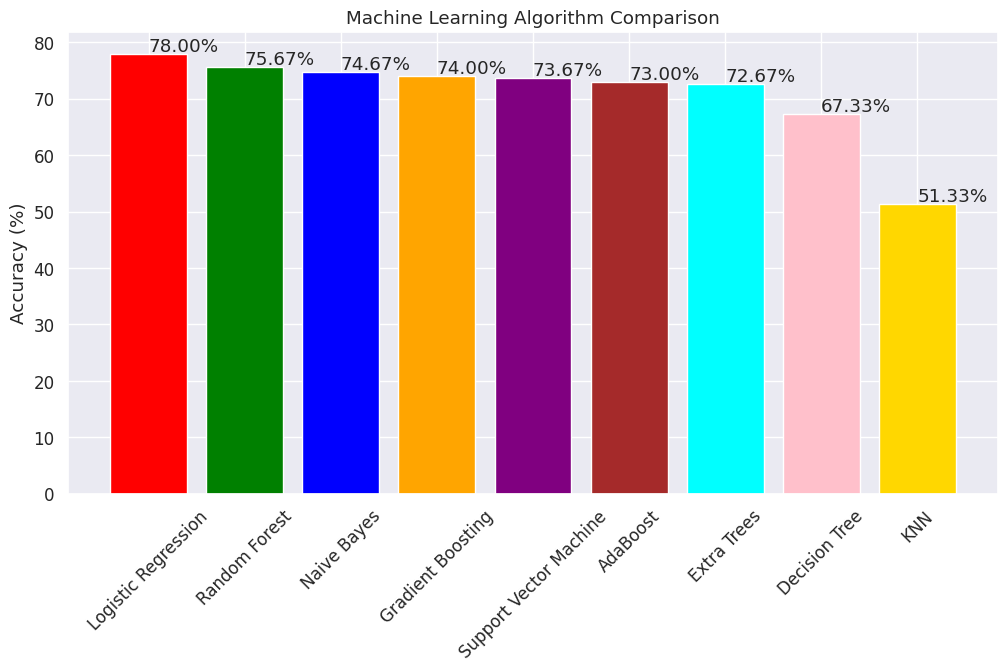

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(

result_df["Model"],

result_df["Accuracy"],

color=[
"red",
"green",
"blue",
"orange",
"purple",
"brown",
"cyan",
"pink",
"gold"
]

)

plt.xticks(rotation=45)

plt.ylabel("Accuracy (%)")

plt.title("Machine Learning Algorithm Comparison")

for i,v in enumerate(result_df["Accuracy"]):

    plt.text(i,v+0.5,f"{v:.2f}%")

plt.show()

In [27]:
best_model = result_df.iloc[0]

print(best_model)

Model        Logistic Regression
Accuracy                    78.0
Precision              78.088958
Recall                      78.0
F1 Score               78.040816
Name: 0, dtype: object


## Thank you...pls upvote!!!!!!!!!!